# Provisionnement Non-Vie — Phase 4 : Analyse de sensibilité

**Auteur :** Hong Phuc QUACH

Analyse de sensibilité :
- **(A)** Loss ratio a priori (60/65/70/75 %) → impact sur l'Ultimate BF
- **(B)** Inflation non anticipée → impact sur l'Ultimate Chain-Ladder

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import chainladder as cl
from phase4_sensitivity import (
    load_triangle, sensitivity_loss_ratio, sensitivity_inflation,
)

pd.set_option('display.float_format', lambda x: f'{x:,.0f}')
triangle = load_triangle()
premium = pd.Series({ay: 5_000_000 + i * 150_000 for i, ay in enumerate(triangle.index)})

## (A) Sensibilité au Loss Ratio a priori

In [2]:
lr_sensitivity = sensitivity_loss_ratio(triangle, premium)
lr_sensitivity.style.format('{:,.0f}').background_gradient(cmap='Oranges', axis=1)

,LR_60%,LR_65%,LR_70%,LR_75%
2001,"3,901,463","3,901,463","3,901,463","3,901,463"
2002,"5,392,901","5,397,385","5,401,870","5,406,354"
2003,"5,186,893","5,210,025","5,233,156","5,256,288"
2004,"5,026,274","5,062,775","5,099,275","5,135,776"
2005,"4,554,474","4,611,238","4,668,001","4,724,765"
2006,"4,649,836","4,729,679","4,809,523","4,889,367"
2007,"4,844,932","4,958,415","5,071,899","5,185,382"
2008,"4,961,936","5,136,722","5,311,509","5,486,295"
2009,"4,184,461","4,419,559","4,654,656","4,889,753"
2010,"3,890,284","4,185,806","4,481,329","4,776,851"


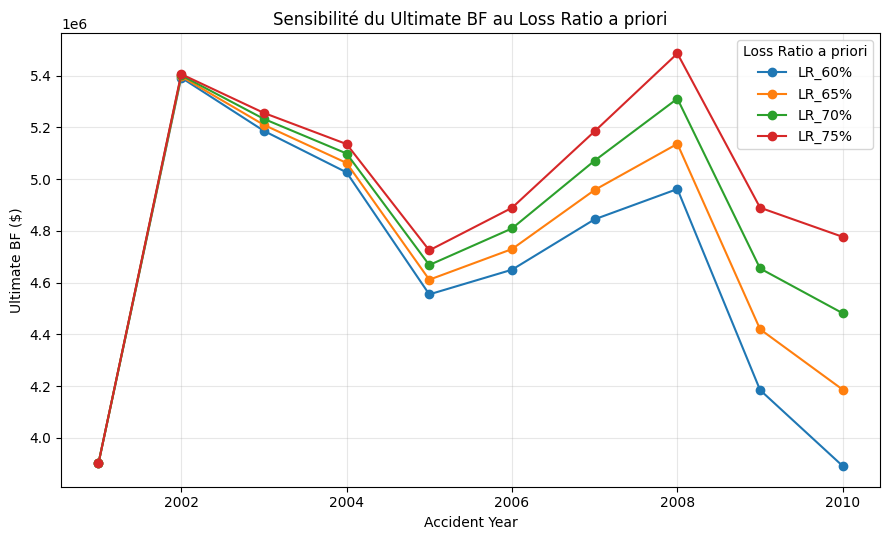

In [3]:
ax = lr_sensitivity.plot(marker='o', figsize=(9, 5.5))
ax.set_title('Sensibilité du Ultimate BF au Loss Ratio a priori')
ax.set_xlabel('Accident Year')
ax.set_ylabel('Ultimate BF ($)')
ax.legend(title='Loss Ratio a priori')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## (B) Sensibilité à l'inflation non anticipée

In [4]:
infl_sensitivity = sensitivity_inflation(triangle)
infl_sensitivity.style.format('{:,.0f}').background_gradient(cmap='Reds', axis=1)

,Inflation_0%,Inflation_2%,Inflation_5%,Inflation_8%
2001,"3,901,463","3,901,463","3,901,463","3,901,463"
2002,"5,433,719","5,435,611","5,438,451","5,441,290"
2003,"5,378,826","5,390,128","5,407,220","5,424,481"
2004,"5,297,906","5,323,452","5,362,753","5,403,242"
2005,"4,858,200","4,901,792","4,969,882","5,041,312"
2006,"5,111,171","5,186,340","5,305,517","5,432,787"
2007,"5,660,771","5,789,240","5,995,658","6,219,677"
2008,"6,784,799","7,020,264","7,402,268","7,821,899"
2009,"5,642,266","5,927,575","6,395,379","6,916,037"
2010,"4,969,825","5,318,673","5,897,640","6,551,610"


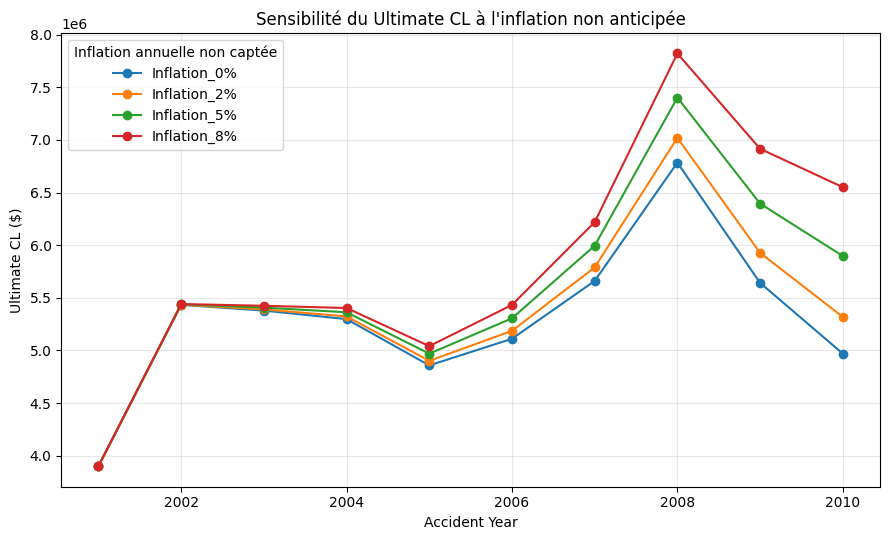

In [5]:
ax = infl_sensitivity.plot(marker='o', figsize=(9, 5.5))
ax.set_title("Sensibilité du Ultimate CL à l'inflation non anticipée")
ax.set_xlabel('Accident Year')
ax.set_ylabel('Ultimate CL ($)')
ax.legend(title='Inflation annuelle non captée')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Tableau de synthèse

In [6]:
lr_total = lr_sensitivity.sum()
infl_total = infl_sensitivity.sum()
summary = pd.DataFrame({
    'Scenario': ['LR 60%', 'LR 65%', 'LR 70%', 'LR 75%',
                 'Inflation 0%', 'Inflation 2%', 'Inflation 5%', 'Inflation 8%'],
    'Ultimate_total': list(lr_total.values) + list(infl_total.values),
})
summary['Ecart_vs_base_%'] = (
    (summary['Ultimate_total'] - summary['Ultimate_total'].iloc[1])
    / summary['Ultimate_total'].iloc[1] * 100
)
summary.style.format({'Ultimate_total': '{:,.0f}', 'Ecart_vs_base_%': '{:+.1f}%'})\
    .background_gradient(subset=['Ecart_vs_base_%'], cmap='coolwarm')

,Scenario,Ultimate_total,Ecart_vs_base_%
0,LR 60%,"46,593,453",-2.1%
1,LR 65%,"47,613,067",+0.0%
2,LR 70%,"48,632,681",+2.1%
3,LR 75%,"49,652,294",+4.3%
4,Inflation 0%,"53,038,946",+11.4%
5,Inflation 2%,"54,194,540",+13.8%
6,Inflation 5%,"56,076,230",+17.8%
7,Inflation 8%,"58,153,797",+22.1%


**Insight 1 :** le BF est plus stable que le Chain-Ladder sur les accident years récentes (β faible → poids sur l'a priori). 

**Insight 2 :** une inflation non anticipée de +8 %/an fait augmenter l'ultimate total Chain-Ladder d'environ +22 % par rapport au scénario de base.